In [8]:
import numpy as np
import soundfile as sf
import scipy.signal as signal
import matplotlib.pyplot as plt

In [3]:
# ========================
# STEP 1: Generate Test Sweep
# ========================

def generate_log_sweep(duration=10, sample_rate=44100, f_start=20, f_end=20000):
    """Generate logarithmic sine sweep for recording"""
    t = np.linspace(0, duration, int(sample_rate * duration))
    sweep = np.sin(2 * np.pi * f_start * duration / np.log(f_end/f_start) * 
                   (np.exp(t * np.log(f_end/f_start) / duration) - 1))
    return sweep / np.max(np.abs(sweep))

# Generate test sweep
sweep = generate_log_sweep()
sf.write('test_sweep.wav', sweep, samplerate=44100)
print("Generated test_sweep.wav")

Generated test_sweep.wav


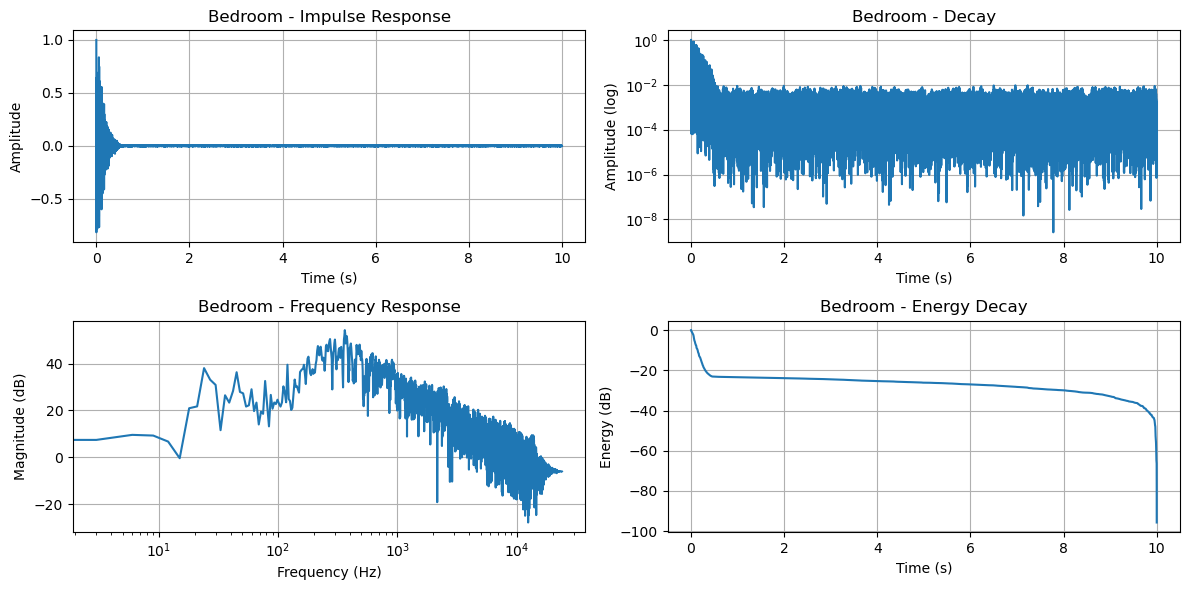

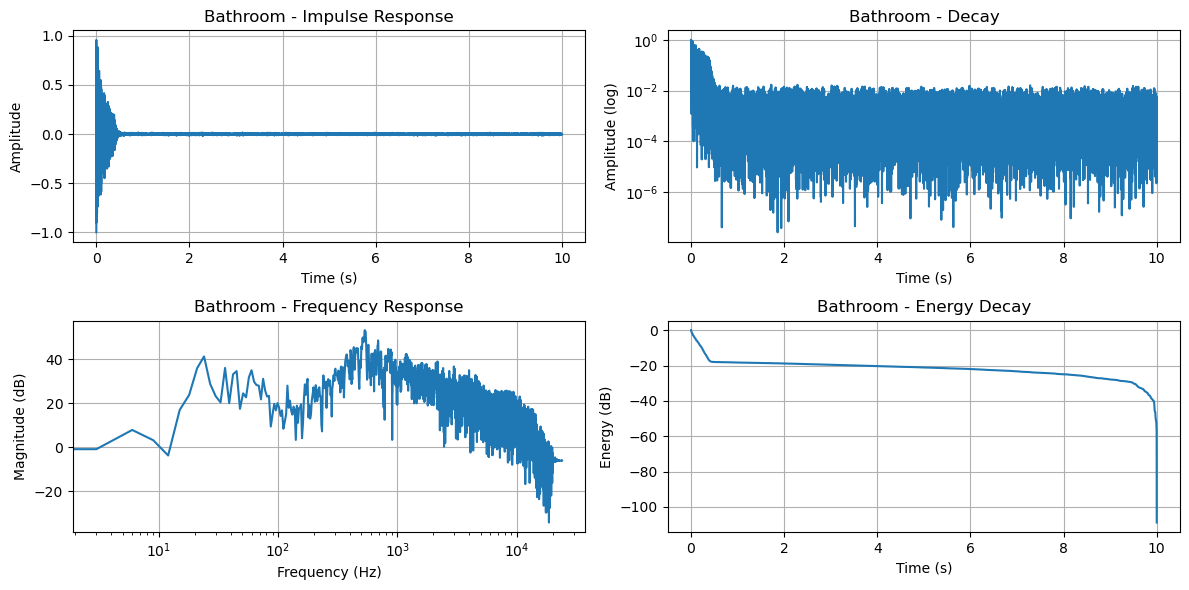

Reverb applied and saved to piano_bedroom_reverb.wav
Reverb applied and saved to vocal_bathroom_reverb.wav


In [9]:
# ========================
# STEP 2: Extract Impulse Response
# ========================

def extract_impulse_response(recorded_file, original_sweep_file, ir_length=10.0):
    """Extract impulse response from recorded sweep"""
    
    # Load files
    recorded, sr = sf.read(recorded_file)
    original, sr_orig = sf.read(original_sweep_file)
    
    # Create inverse filter (time-reversed sweep)
    inverse_sweep = original[::-1]
    
    # Deconvolve by convolving with inverse
    impulse_response = signal.convolve(recorded, inverse_sweep, mode='full')
    
    # Find peak and extract IR
    peak_idx = np.argmax(np.abs(impulse_response))
    ir_samples = int(ir_length * sr)
    final_ir = impulse_response[peak_idx:peak_idx + ir_samples]
    
    # Normalize
    return final_ir / np.max(np.abs(final_ir)), sr

# ========================
# STEP 3: Apply Convolution Reverb
# ========================

def apply_convolution_reverb(dry_audio_file, impulse_response, output_file, 
                           wet_level=0.5, dry_level=0.5):
    """Apply convolution reverb to audio file"""
    
    # Load dry audio
    dry_audio, sr = sf.read(dry_audio_file)
    
    # Convolve with impulse response
    wet_audio = signal.convolve(dry_audio, impulse_response, mode='full')
    
    # Mix dry and wet (trim to shortest length)
    min_length = min(len(dry_audio), len(wet_audio))
    mixed_audio = (dry_level * dry_audio[:min_length] + 
                  wet_level * wet_audio[:min_length])
    
    # Normalize and save
    mixed_audio = mixed_audio / np.max(np.abs(mixed_audio)) * 0.95
    sf.write(output_file, mixed_audio, samplerate=sr)
    print(f"Reverb applied and saved to {output_file}")

# ========================
# STEP 4: Analyze Impulse Response
# ========================

def analyze_impulse_response(impulse_response, sample_rate, space_name):
    """Analyze and plot impulse response"""
    
    t = np.arange(len(impulse_response)) / sample_rate
    
    plt.figure(figsize=(12, 6))
    
    # Waveform
    plt.subplot(2, 2, 1)
    plt.plot(t, impulse_response)
    plt.title(f'{space_name} - Impulse Response')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    
    # Decay envelope
    plt.subplot(2, 2, 2)
    envelope = np.abs(impulse_response)
    plt.plot(t, envelope)
    plt.yscale('log')
    plt.title(f'{space_name} - Decay')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (log)')
    plt.grid(True)
    
    # Frequency response
    plt.subplot(2, 2, 3)
    freqs, h = signal.freqz(impulse_response, worN=8000, fs=sample_rate)
    plt.plot(freqs, 20 * np.log10(np.abs(h)))
    plt.title(f'{space_name} - Frequency Response')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.grid(True)
    plt.xscale('log')
    
    # RT60 estimate
    plt.subplot(2, 2, 4)
    energy = np.cumsum(impulse_response[::-1]**2)[::-1]
    energy_db = 10 * np.log10(energy / np.max(energy))
    plt.plot(t, energy_db)
    plt.title(f'{space_name} - Energy Decay')
    plt.xlabel('Time (s)')
    plt.ylabel('Energy (dB)')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# ========================
# EXAMPLE USAGE
# ========================

# Process your recordings (uncomment and modify):

# Extract impulse responses
bedroom_ir, sr = extract_impulse_response('bedroom_recorded.wav', 'test_sweep.wav')
bathroom_ir, sr = extract_impulse_response('bathroom_recorded.wav', 'test_sweep.wav')

# Save impulse responses
sf.write('bedroom_ir.wav', bedroom_ir, samplerate=sr)
sf.write('bathroom_ir.wav', bathroom_ir, samplerate=sr)

# Analyze spaces
analyze_impulse_response(bedroom_ir, sr, 'Bedroom')
analyze_impulse_response(bathroom_ir, sr, 'Bathroom')

# Apply reverb to dry audio
apply_convolution_reverb('dry_piano.wav', bedroom_ir, 'piano_bedroom_reverb.wav')
apply_convolution_reverb('dry_vocal.wav', bathroom_ir, 'vocal_bathroom_reverb.wav')
